# Bank Loan Analysis Project

## 导入 Python 工具库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import plotly.express as px

In [2]:
df = pd.read_csv("信用风控数据.csv")

In [3]:
df.head()


,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314.0,Short Term,747.0,2074116.0,10+ years,Home Mortgage,Debt Consolidation,42000.83,21.8,NaN,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662.0,Short Term,734.0,1919190.0,10+ years,Home Mortgage,Debt Consolidation,36624.40,19.4,NaN,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494.0,Short Term,709.0,871112.0,2 years,Rent,Debt Consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242.0,Short Term,727.0,780083.0,10+ years,Rent,Debt Consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992.0,Short Term,744.0,1761148.0,10+ years,Home Mortgage,Debt Consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


## 数据集基础信息

In [4]:
print("No. of Rows:", df.shape[0])

No. of Rows: 10353


In [5]:
print("No. of columns:", df.shape[1])

No. of columns: 18


### 数据类型

In [6]:
df.dtypes

Loan ID                          object
Customer ID                      object
Current Loan Amount             float64
Term                             object
Credit Score                    float64
Annual Income                   float64
Years in current job             object
Home Ownership                   object
Purpose                          object
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts         float64
Number of Credit Problems       float64
Current Credit Balance          float64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

In [11]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+04,8019.000000,8.019000e+03,10000.000000,10000.000000,4694.000000,10000.00000,10000.000000,1.000000e+04,1.000000e+04,9978.000000,9999.000000
mean,1.160380e+07,1077.991520,1.369106e+06,18429.671699,18.235930,34.964636,11.08410,0.165500,2.907301e+05,6.871308e+05,0.116356,0.030803
std,3.160010e+07,1477.467761,8.687557e+05,12399.956192,7.018356,21.640291,5.02338,0.500934,3.881687e+05,1.861394e+06,0.349961,0.288215
min,1.947000e+04,585.000000,8.109200e+04,0.000000,3.800000,0.000000,1.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.789480e+05,706.000000,8.483405e+05,10202.857500,13.600000,17.000000,7.00000,0.000000,1.086515e+05,2.706000e+05,0.000000,0.000000
50%,3.092760e+05,725.000000,1.168272e+06,16052.055000,17.000000,32.000000,10.00000,0.000000,2.075180e+05,4.626050e+05,0.000000,0.000000
75%,5.157075e+05,741.000000,1.664390e+06,23881.337500,21.700000,50.000000,14.00000,0.000000,3.624630e+05,7.861150e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.781535e+07,229057.920000,62.500000,131.000000,55.00000,10.000000,1.623744e+07,1.459073e+08,5.000000,9.000000


### 总贷款申请量

In [8]:
total_loan_application = df['Loan ID'].count()
print("Total Loan Applications:", total_loan_application)

Total Loan Applications: 10000


### 总放款金额

In [12]:
total_funded_amount = df['Current Loan Amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M". format(total_funded_amount_millions))

Total Funded Amount: $116038.01M


### 总回款金额

In [15]:
total_amount_received = (df['Current Loan Amount'] - df['Current Credit Balance']).sum()
total_amount_received_millions = total_amount_received / 1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $113130.71M


### 平均负债收入比(DTI)

In [16]:
df['DTI'] = df['Monthly Debt'] / (df['Annual Income'] / 12) * 100

average_dti = df['DTI'].mean()
print(f"Average DTI:{average_dti:.2f}%")

Average DTI:17.26%


### 优质贷款统计

In [17]:
good_loan = df[
    (df['Months since last delinquent'].isna()) &  # 核心改动：NA=从未逾期
    (df['Number of Credit Problems'] == 0) &
    (df['Bankruptcies'] == 0) &
    (df['Tax Liens'] == 0)
]

total_loan_applications = df['Loan ID'].count()

good_loan_applications = good_loan['Loan ID'].count()
good_loan_funded_amount = good_loan['Current Loan Amount'].sum()
good_loan_received = (good_loan['Current Loan Amount'] - good_loan['Current Credit Balance']).sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_recived_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print(f"Good Loan Funded Amount(in Millions):${good_loan_funded_amount_millions:.2f}M")
print(f"Good Loan Total Received(in Millions):${good_loan_recived_millions:.2f}M")
print(f"Percentage of Good Loan Applications:{good_loan_percentage:.2f}%")

Good Loan Applications: 4611
Good Loan Funded Amount(in Millions):$57172.88M
Good Loan Total Received(in Millions):$55601.86M
Percentage of Good Loan Applications:46.11%


### 劣质贷款

In [18]:
bad_loan = df[df['Months since last delinquent'].notna()]

total_loan_applications = df['Loan ID'].count()

bad_loan_applications = bad_loan['Loan ID'].count()
bad_loan_funded_amount = bad_loan['Current Loan Amount'].sum()

bad_loan_received = (bad_loan['Current Loan Amount'] - bad_loan['Current Credit Balance']).sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_recived_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print(f"Bad Loan Funded Amount(in Millions):${bad_loan_funded_amount_millions:.2f}M")
print(f"Bad Loan Total Received(in Millions):${bad_loan_recived_millions:.2f}M")
print(f"Percentage of Bad Loan Applications:{bad_loan_percentage:.2f}%")

Bad Loan Applications: 4694
Bad Loan Funded Amount(in Millions):$51501.79M
Bad Loan Total Received(in Millions):$50290.94M
Percentage of Bad Loan Applications:46.94%


### 信用分数 vs 贷款金额

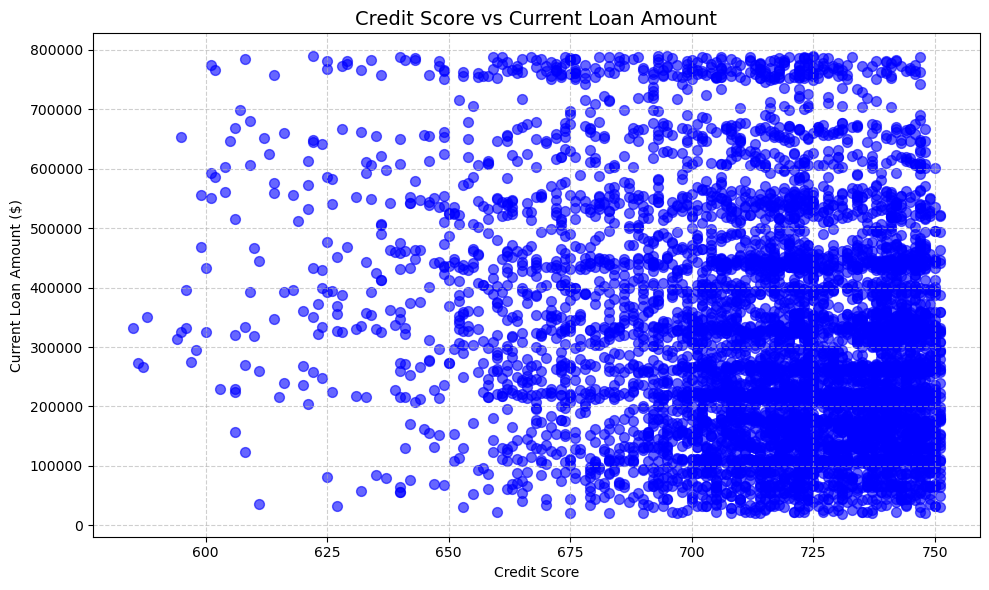

In [21]:
#清洗数据
df_clean = df[(df['Credit Score'] < 1000) & (df['Current Loan Amount'] < 1000000)]

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Credit Score'], df_clean['Current Loan Amount'],
            alpha=0.6, color='blue', s=50)

plt.title('Credit Score vs Current Loan Amount', fontsize=14)
plt.xlabel('Credit Score')
plt.ylabel('Current Loan Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 不同住房所有制的贷款金额分布

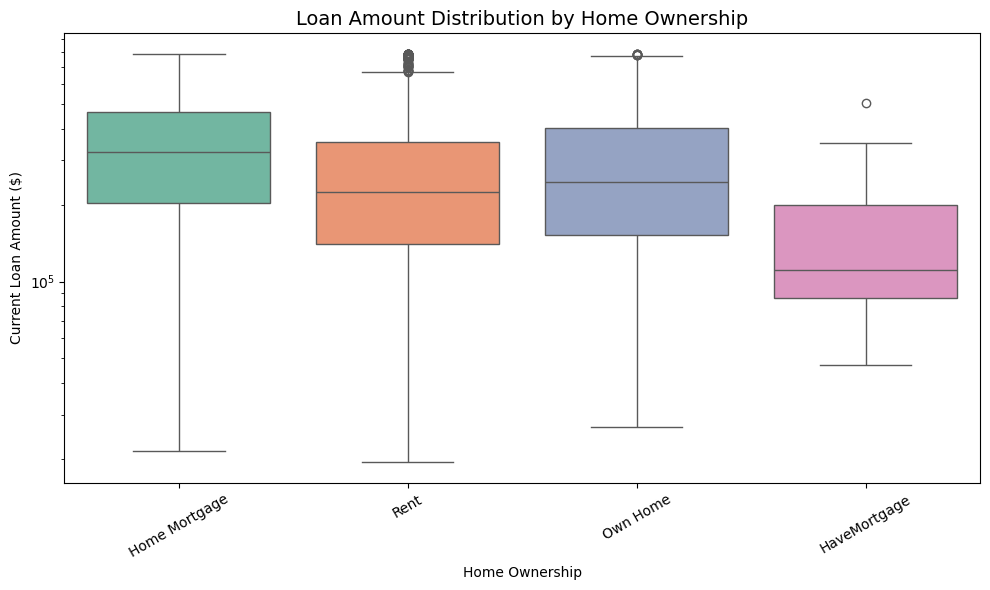

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_clean = df[(df['Credit Score'] < 1000) & (df['Current Loan Amount'] < 1000000)]

plt.figure(figsize=(10, 6))

sns.boxplot(x='Home Ownership', y='Current Loan Amount', 
            hue='Home Ownership', data=df_clean, palette='Set2', legend=False)

plt.xticks(rotation=30)
plt.yscale('log')

plt.title('Loan Amount Distribution by Home Ownership', fontsize=14)
plt.xlabel('Home Ownership')
plt.ylabel('Current Loan Amount ($)')

plt.tight_layout()
plt.show()

### 年收入 vs 月负债

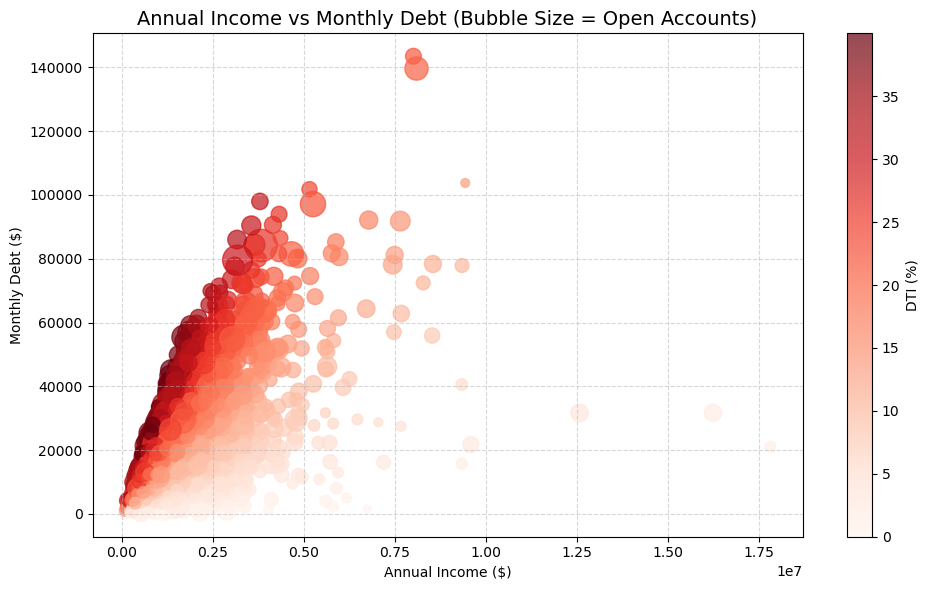

In [27]:
df['DTI_Calculated'] = df['Monthly Debt'] / (df['Annual Income'] / 12) * 100

plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income'], df['Monthly Debt'], 
            c=df['DTI_Calculated'], 
            cmap='Reds', 
            s=df['Number of Open Accounts']*10, 
            alpha=0.7)

plt.colorbar(label='DTI (%)') 
plt.title('Annual Income vs Monthly Debt (Bubble Size = Open Accounts)', fontsize=14)
plt.xlabel('Annual Income ($)')
plt.ylabel('Monthly Debt ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 从业长度分析

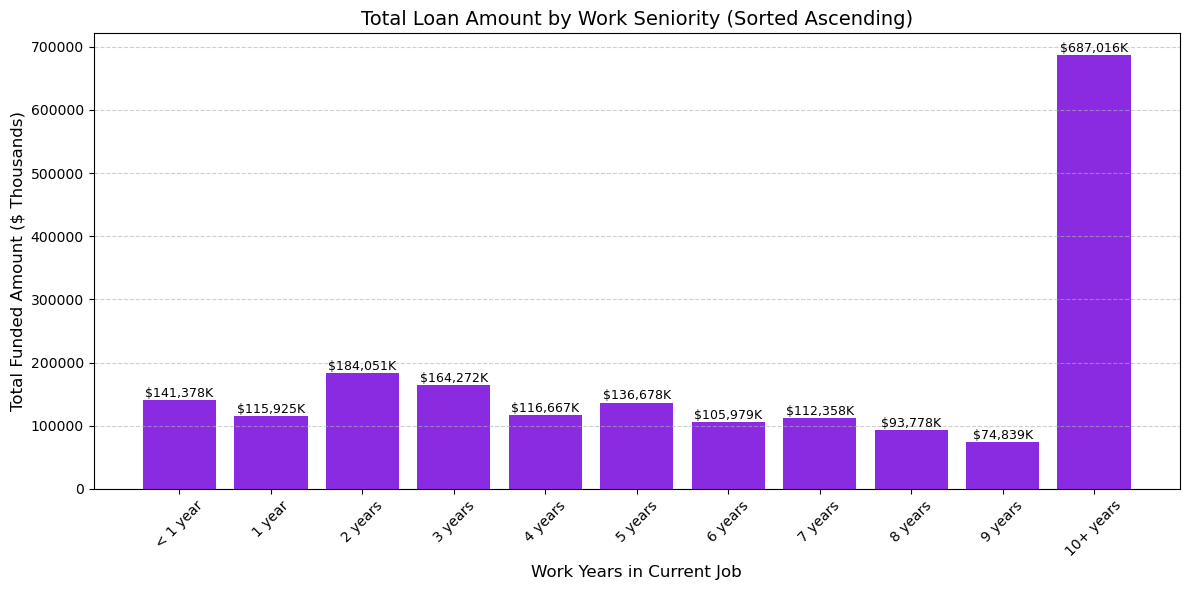

In [30]:
warnings.filterwarnings('ignore')

df_clean = df[(df['Credit Score'] < 1000) & (df['Current Loan Amount'] < 1000000)]

work_year_order = [
    '< 1 year', '1 year', '2 years', '3 years', '4 years',
    '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years'
]

emp_funding = df_clean.groupby('Years in current job')['Current Loan Amount'].sum()
emp_funding = emp_funding.reindex(work_year_order)  # 强制排序
emp_funding_k = emp_funding / 1000  # 单位：千美元

plt.figure(figsize=(12, 6))

bars = plt.bar(emp_funding_k.index, emp_funding_k, color='#8A2BE2')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.xlabel('Work Years in Current Job', fontsize=12)
plt.ylabel('Total Funded Amount ($ Thousands)', fontsize=12)
plt.title('Total Loan Amount by Work Seniority (Sorted Ascending)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 贷款用途拆分图

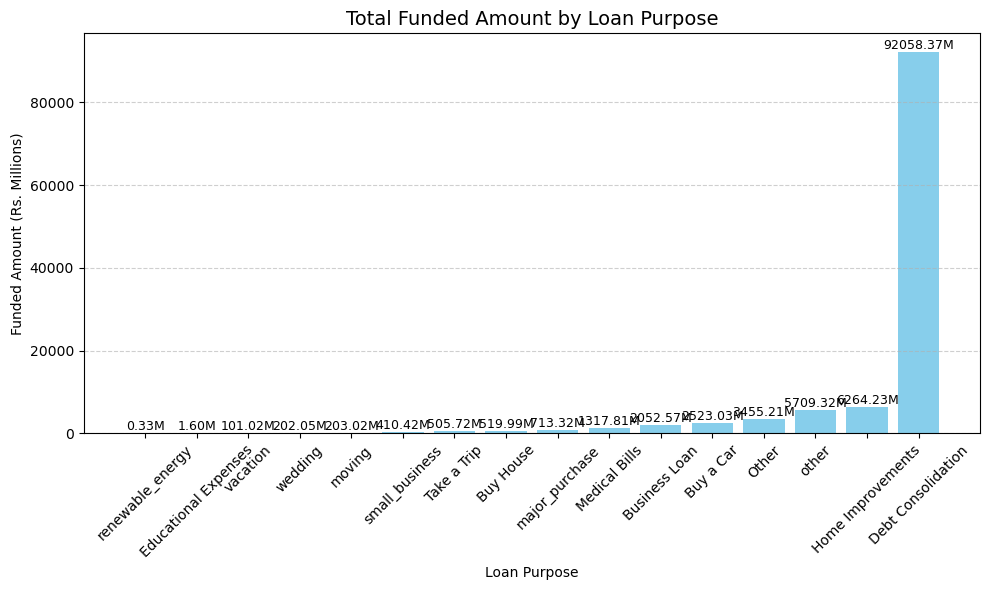

In [31]:
import os

purpose_funding_millions = (df.groupby('Purpose')['Current Loan Amount'].sum().sort_values()/1000000)

plt.figure(figsize=(10, 6))
bars = plt.bar(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.2f}M', ha='center', va='bottom', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose', fontsize=14)
plt.xlabel('Loan Purpose')
plt.ylabel('Funded Amount (Rs. Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45) 
plt.tight_layout()

if not os.path.exists('charts'):
    os.makedirs('charts')
plt.savefig('charts/Loan_Purpose_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()